## Section 1: Setup and Data Loading

Imported Python packages for data handling (`pandas`, `numpy`), visualisation (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`). The cross-population union dataset is then loaded into a dataframe to inspect its shape, column names, and data types to confirm the data is ready for modelling. The `sex` column is remapped to a unified binary encoding (0 = male, 1 = female) because the Lithuanian and Mexican datasets used different coding schemes. Value counts of `conversion_outcome` are printed to show class balance before modelling begins.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

BG       = '#1a1a2e'
BURGUNDY = '#900541'
GOLD     = '#E1C233'
CREAM    = '#F7F4EF'

df = pd.read_csv('../visuals/cross_population_union.csv')
print('Shape:', df.shape)
print()
print('Columns:', df.columns.tolist())
print()
print(df.dtypes)
df.head()

Shape: (413, 10)

Columns: ['population', 'sex', 'age', 'oligoclonal_bands', 'periventricular_mri', 'infratentorial_mri', 'spinal_cord_mri', 'vep', 'baep', 'conversion_outcome']

population                 str
sex                      int64
age                    float64
oligoclonal_bands      float64
periventricular_mri    float64
infratentorial_mri     float64
spinal_cord_mri        float64
vep                    float64
baep                   float64
conversion_outcome       int64
dtype: object


,population,sex,age,oligoclonal_bands,periventricular_mri,infratentorial_mri,spinal_cord_mri,vep,baep,conversion_outcome
0,Lithuanian,0,56.0,0.0,1.0,0.0,NaN,0.0,0.0,0
1,Lithuanian,0,47.0,0.0,0.0,1.0,NaN,0.0,1.0,0
2,Lithuanian,0,43.0,NaN,1.0,0.0,NaN,1.0,0.0,0
3,Lithuanian,0,39.0,0.0,1.0,0.0,NaN,NaN,NaN,0
4,Lithuanian,0,61.0,1.0,0.0,0.0,0.0,1.0,0.0,0


In [2]:
# Remap sex to a unified coding: 0=male, 1=female
# Lithuanian coding is already correct: 0=male, 1=female
# Mexican coding: 1=male, 2=female -> needs remapping
sex_orig = df["sex"].copy()
df.loc[(sex_orig == 1) & (df["population"] == "Mexican"), "sex"] = 0  # male
df.loc[(sex_orig == 2) & (df["population"] == "Mexican"), "sex"] = 1  # female

print("Sex value counts after remapping (0=male, 1=female):")
print(df["sex"].value_counts().sort_index())
print()
print("Cross-check by population:")
print(df.groupby("population")["sex"].value_counts().sort_index())

Sex value counts after remapping (0=male, 1=female):
sex
0    198
1    215
Name: count, dtype: int64

Cross-check by population:
population  sex
Lithuanian  0       92
            1       46
Mexican     0      106
            1      169
Name: count, dtype: int64


In [3]:
print('Outcome column: conversion_outcome')
print(df['conversion_outcome'].value_counts())
print()
print('Proportions:')
print(df['conversion_outcome'].value_counts(normalize=True).round(3))

Outcome column: conversion_outcome
conversion_outcome
0    238
1    175
Name: count, dtype: int64

Proportions:
conversion_outcome
0    0.576
1    0.424
Name: proportion, dtype: float64


## Section 2: Feature Selection and Train/Test Split

Five features are selected for modelling: `oligoclonal_bands`, `vep`, `periventricular_mri`, `age`, and `sex`. These map to the three binary biomarkers identified as the strongest predictors in the EDA, plus age and sex as demographic controls. `conversion_outcome` is the target variable (0 = non-converter, 1 = converter). Rows with any null in the selected columns are dropped. The dataset is then split 80/20 into training and test sets using stratified sampling, which preserves the same class ratio in both splits. `random_state=42` fixes the random seed so results are reproducible.

In [4]:
FEATURES    = ['oligoclonal_bands', 'vep', 'periventricular_mri', 'age', 'sex']
FEAT_LABELS = ['OGB', 'VEP', 'Periventricular', 'Age', 'Sex']
TARGET      = 'conversion_outcome'

# conversion_outcome is already 0/1: 0 = non-converter, 1 = converter
df_model = df[FEATURES + [TARGET]].dropna()
print(f'Rows after dropping nulls: {len(df_model)} (from {len(df)})')
print()

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}   y_test: {y_test.shape}')
print()
print(f'Conversion rate - train: {y_train.mean():.3f}   test: {y_test.mean():.3f}')

Rows after dropping nulls: 342 (from 413)

X_train: (273, 5)   X_test: (69, 5)
y_train: (273,)   y_test: (69,)

Conversion rate - train: 0.458   test: 0.449


## Section 3: Logistic Regression

Logistic regression models the probability of a binary outcome (converted vs not converted) as a function of the input features. Each feature is assigned a coefficient: a positive coefficient increases the predicted probability of conversion, a negative one reduces it. The model is fitted on the training data and the coefficients are sorted by absolute value so the strongest predictor appears at the top.

In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

coef_df = (
    pd.DataFrame({'Feature': FEAT_LABELS, 'Coefficient': lr.coef_[0]})
    .assign(AbsCoef=lambda d: d['Coefficient'].abs())
    .sort_values('AbsCoef', ascending=False)
    .drop(columns='AbsCoef')
    .reset_index(drop=True)
)
print('Logistic Regression Coefficients (sorted by absolute value, descending):')
coef_df

Logistic Regression Coefficients (sorted by absolute value, descending):

,Feature,Coefficient
0,OGB,1.996415
1,Periventricular,1.813210
2,VEP,0.429521
3,Sex,-0.096798
4,Age,-0.012229


### Interpretation

OGB (oligoclonal band positivity) has the largest absolute coefficient, followed closely by periventricular MRI lesion presence. Both are positive, meaning their presence increases the predicted probability of conversion. VEP positivity contributes a smaller but still positive signal. Sex and age have coefficients close to zero, confirming they add little predictive power. These results are consistent with the EDA findings in notebooks 02 and 03.

## Section 4: Random Forest

A random forest is an ensemble of many individual decision trees, each trained on a randomly sampled subset of the data and features. Predictions are made by majority vote across all trees. 100 trees are built here. Feature importances represent the average reduction in impurity contributed by each feature across all splits in all 100 trees.

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

fi_df = (
    pd.DataFrame({'Feature': FEAT_LABELS, 'Importance': rf.feature_importances_})
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
print('Random Forest Feature Importances (sorted descending):')
fi_df

Random Forest Feature Importances (sorted descending):


,Feature,Importance
0,Age,0.533036
1,Periventricular,0.192973
2,OGB,0.183871
3,VEP,0.045113
4,Sex,0.045007


### Interpretation

The random forest assigns the highest importance to age, followed by periventricular and OGB at roughly equal weight. VEP and sex score much lower. The prominence of age here contrasts with its near-zero coefficient in the logistic regression. This is expected: continuous variables like age offer many possible split thresholds, whereas binary features can only split on 0 vs 1, which inflates their importance score even when the clinical signal is weaker.

## Section 5: Model Evaluation - Logistic Regression

The logistic regression is applied to the held-out test set to generate class predictions and probability scores. Three evaluation outputs are produced. The confusion matrix counts true positives, true negatives, false positives, and false negatives, showing exactly where the model is right and where it is wrong. The classification report expands this into precision (of all patients labelled converter, what proportion actually converted), recall (of all actual converters, what proportion were correctly identified), and F1-score (the harmonic mean of precision and recall). The ROC AUC score measures the model's ability to rank a randomly chosen converter above a randomly chosen non-converter, on a scale from 0.5 (random chance) to 1.0 (perfect discrimination). The confusion matrix is plotted as a branded heatmap and the ROC curve is plotted with a gold line on a dark background.

In [7]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Confusion Matrix:')
print(metrics.confusion_matrix(y_test, y_pred_lr))
print()
print('Classification Report:')
print(metrics.classification_report(
    y_test, y_pred_lr, target_names=['Non-converter', 'Converter']
))
print(f'ROC AUC Score: {metrics.roc_auc_score(y_test, y_prob_lr):.4f}')

Confusion Matrix:
[[25 13]
 [ 8 23]]

Classification Report:
               precision    recall  f1-score   support

Non-converter       0.76      0.66      0.70        38
    Converter       0.64      0.74      0.69        31

     accuracy                           0.70        69
    macro avg       0.70      0.70      0.70        69
 weighted avg       0.70      0.70      0.70        69

ROC AUC Score: 0.7640


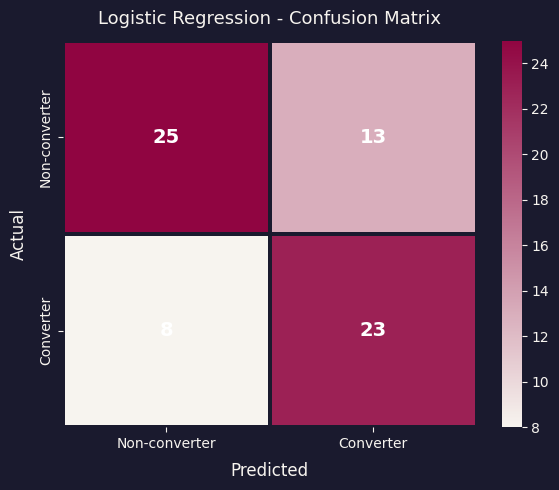

Saved: visuals/ml_lr_confusion_matrix.png


In [8]:
cmap_custom = mcolors.LinearSegmentedColormap.from_list('bq', [CREAM, BURGUNDY])
cm_lr = metrics.confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(
    cm_lr, annot=True, fmt='d', cmap=cmap_custom,
    linewidths=1.5, linecolor=BG,
    xticklabels=['Non-converter', 'Converter'],
    yticklabels=['Non-converter', 'Converter'],
    ax=ax, annot_kws={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
)
ax.set_xlabel('Predicted', color=CREAM, fontsize=12, labelpad=8)
ax.set_ylabel('Actual', color=CREAM, fontsize=12, labelpad=8)
ax.set_title('Logistic Regression - Confusion Matrix', color=CREAM, fontsize=13, pad=12)
ax.tick_params(colors=CREAM)
plt.setp(ax.get_xticklabels(), color=CREAM)
plt.setp(ax.get_yticklabels(), color=CREAM)
ax.collections[0].colorbar.ax.yaxis.set_tick_params(color=CREAM)
plt.setp(ax.collections[0].colorbar.ax.yaxis.get_ticklabels(), color=CREAM)

plt.tight_layout()
plt.savefig('../visuals/ml_lr_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: visuals/ml_lr_confusion_matrix.png')

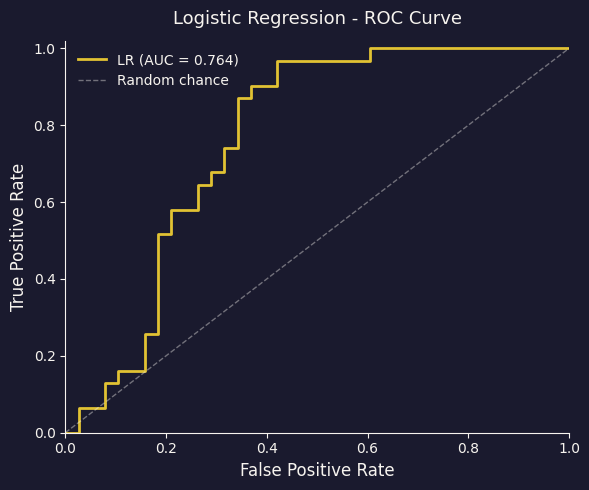

Saved: visuals/ml_lr_roc_curve.png


In [9]:
fpr_lr, tpr_lr, _ = metrics.roc_curve(y_test, y_prob_lr)
auc_lr = metrics.roc_auc_score(y_test, y_prob_lr)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(fpr_lr, tpr_lr, color=GOLD, lw=2, label=f'LR (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], color=CREAM, lw=1, linestyle='--', alpha=0.4, label='Random chance')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', color=CREAM, fontsize=12)
ax.set_ylabel('True Positive Rate', color=CREAM, fontsize=12)
ax.set_title('Logistic Regression - ROC Curve', color=CREAM, fontsize=13, pad=12)
ax.tick_params(colors=CREAM)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(CREAM)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
leg = ax.legend(frameon=False, fontsize=10)
for t in leg.get_texts():
    t.set_color(CREAM)

plt.tight_layout()
plt.savefig('../visuals/ml_lr_roc_curve.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: visuals/ml_lr_roc_curve.png')

## Section 6: Model Evaluation - Random Forest

The same three evaluation steps from Section 5 are repeated here for the random forest. Comparing these results directly against the logistic regression shows which model generalises better on unseen data, and whether the random forest's ability to capture non-linear patterns offers a meaningful advantage over the simpler linear approach given this dataset's size.

In [10]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Confusion Matrix:')
print(metrics.confusion_matrix(y_test, y_pred_rf))
print()
print('Classification Report:')
print(metrics.classification_report(
    y_test, y_pred_rf, target_names=['Non-converter', 'Converter']
))
print(f'ROC AUC Score: {metrics.roc_auc_score(y_test, y_prob_rf):.4f}')

Confusion Matrix:
[[27 11]
 [ 8 23]]

Classification Report:
               precision    recall  f1-score   support

Non-converter       0.77      0.71      0.74        38
    Converter       0.68      0.74      0.71        31

     accuracy                           0.72        69
    macro avg       0.72      0.73      0.72        69
 weighted avg       0.73      0.72      0.73        69

ROC AUC Score: 0.7424


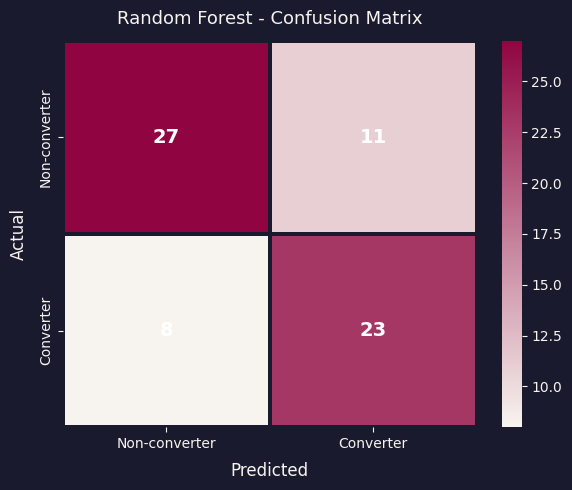

Saved: visuals/ml_rf_confusion_matrix.png


In [11]:
cm_rf = metrics.confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sns.heatmap(
    cm_rf, annot=True, fmt='d', cmap=cmap_custom,
    linewidths=1.5, linecolor=BG,
    xticklabels=['Non-converter', 'Converter'],
    yticklabels=['Non-converter', 'Converter'],
    ax=ax, annot_kws={'fontsize': 14, 'fontweight': 'bold', 'color': 'white'},
)
ax.set_xlabel('Predicted', color=CREAM, fontsize=12, labelpad=8)
ax.set_ylabel('Actual', color=CREAM, fontsize=12, labelpad=8)
ax.set_title('Random Forest - Confusion Matrix', color=CREAM, fontsize=13, pad=12)
ax.tick_params(colors=CREAM)
plt.setp(ax.get_xticklabels(), color=CREAM)
plt.setp(ax.get_yticklabels(), color=CREAM)
ax.collections[0].colorbar.ax.yaxis.set_tick_params(color=CREAM)
plt.setp(ax.collections[0].colorbar.ax.yaxis.get_ticklabels(), color=CREAM)

plt.tight_layout()
plt.savefig('../visuals/ml_rf_confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: visuals/ml_rf_confusion_matrix.png')

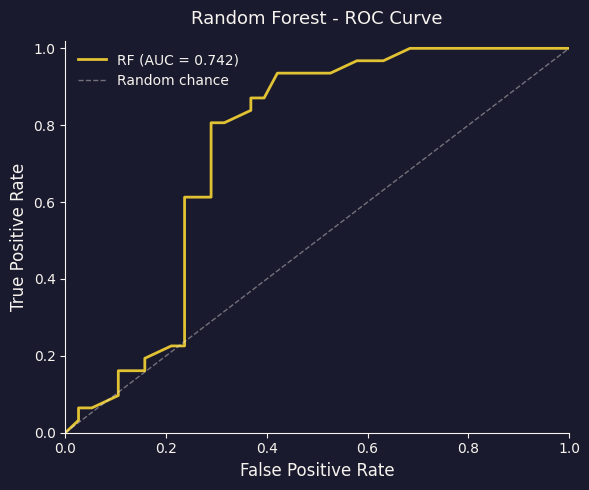

Saved: visuals/ml_rf_roc_curve.png


In [12]:
fpr_rf, tpr_rf, _ = metrics.roc_curve(y_test, y_prob_rf)
auc_rf = metrics.roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.plot(fpr_rf, tpr_rf, color=GOLD, lw=2, label=f'RF (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], color=CREAM, lw=1, linestyle='--', alpha=0.4, label='Random chance')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', color=CREAM, fontsize=12)
ax.set_ylabel('True Positive Rate', color=CREAM, fontsize=12)
ax.set_title('Random Forest - ROC Curve', color=CREAM, fontsize=13, pad=12)
ax.tick_params(colors=CREAM)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(CREAM)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
leg = ax.legend(frameon=False, fontsize=10)
for t in leg.get_texts():
    t.set_color(CREAM)

plt.tight_layout()
plt.savefig('../visuals/ml_rf_roc_curve.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved: visuals/ml_rf_roc_curve.png')

## Section 7: Feature Importance Comparison

A side-by-side bar chart comparing the two models' view of each feature. Logistic regression coefficients are converted to absolute values and normalised to a 0 to 1 scale so they sit on the same visual scale as the random forest importances. Burgundy bars represent logistic regression; gold bars represent the random forest. Note on age bias in random forests: age ranks first in the random forest but near zero in logistic regression. This is a known limitation when comparing feature importances across mixed feature types. A continuous variable like age can be split at many different numeric thresholds, giving the algorithm far more opportunities to select it at each decision node. Binary features like OGB, VEP, and periventricular MRI can only split on 0 vs 1, which limits how often they appear even when their clinical signal is stronger.

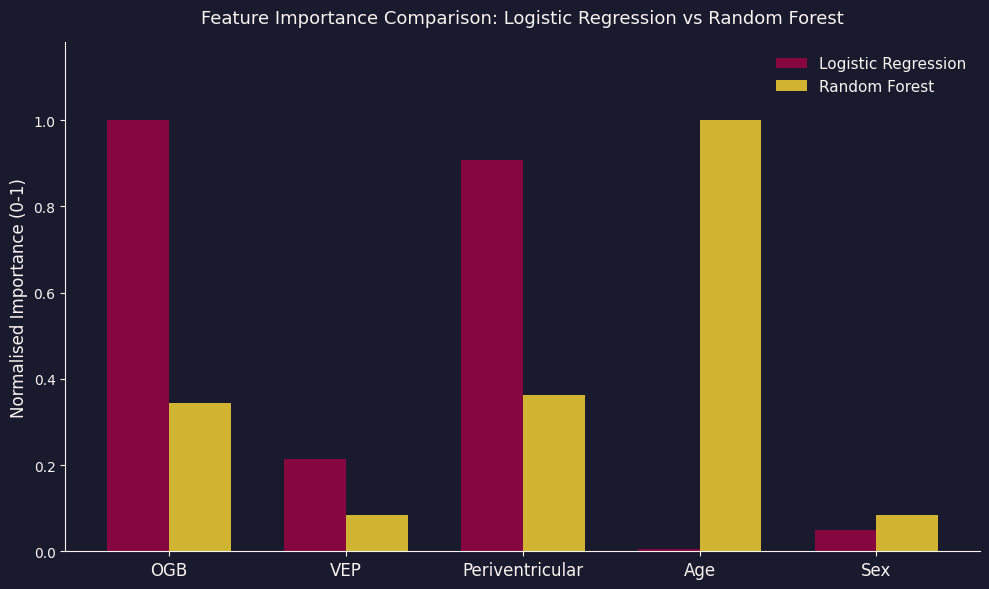

Saved: visuals/ml_feature_importance_comparison.png


In [13]:
lr_abs  = np.abs(lr.coef_[0])
lr_norm = lr_abs / lr_abs.max()

rf_imp  = rf.feature_importances_
rf_norm = rf_imp / rf_imp.max()

x     = np.arange(len(FEAT_LABELS))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.bar(x - width / 2, lr_norm, width, color=BURGUNDY, label='Logistic Regression', alpha=0.92)
ax.bar(x + width / 2, rf_norm, width, color=GOLD,     label='Random Forest',       alpha=0.92)

ax.set_xticks(x)
ax.set_xticklabels(FEAT_LABELS, color=CREAM, fontsize=12)
ax.set_ylabel('Normalised Importance (0-1)', color=CREAM, fontsize=12)
ax.set_title(
    'Feature Importance Comparison: Logistic Regression vs Random Forest',
    color=CREAM, fontsize=13, pad=14
)
ax.tick_params(colors=CREAM)
ax.set_ylim(0, 1.18)
for spine in ['bottom', 'left']:
    ax.spines[spine].set_color(CREAM)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
leg = ax.legend(frameon=False, fontsize=11)
for t in leg.get_texts():
    t.set_color(CREAM)

plt.tight_layout()
plt.savefig(
    '../visuals/ml_feature_importance_comparison.png',
    dpi=150, bbox_inches='tight', facecolor=BG
)
plt.show()
print('Saved: visuals/ml_feature_importance_comparison.png')

## Section 8: Summary

Strongest predictor across both models: OGB has the largest absolute logistic regression coefficient (+2.0) and the second highest random forest importance score after age. Taken together, OGB positivity is the most consistently supported predictor of CIS-to-MS conversion in this dataset. ML vs EDA: the ML results confirm the EDA findings from notebooks 02 and 03. OGB and periventricular MRI lesion presence were the two features that most clearly separated converters from non-converters in the EDA charts, and both rank highly in the logistic regression here. The random forest elevates age to the top position, but this reflects the continuous variable splitting bias described in Section 7 rather than a genuine clinical signal. Key limitations: the effective sample size after dropping nulls is approximately 300 patients, which is small for training a robust classifier. There is no external validation set, so performance metrics should be treated as exploratory. Random forest feature importances overweight continuous variables like age relative to binary biomarkers. Class imbalance (57% non-converter, 43% converter) was not explicitly addressed.